In [26]:
import vcpi
vcpi.login()

Already logged in.


In [27]:
vpci.Client()

NameError: name 'vpci' is not defined

In [25]:
import vcpi_client as vcpi

# 2. Establish client handshake connection to fetch the target compound features
client = vcpi.Client()
compound_features = client.get_compound_features()

# This matrix maps the compound names from your metadata file to SMILES strings
compound_features.head()

ModuleNotFoundError: No module named 'vcpi_client'

In [2]:
import vcpi

# See what datasets you have access to
datasets = vcpi.list_datasets()

# Query metadata and chemistry without downloading anything
df = vcpi.query(
    job="vcpi-0001",
    sql="SELECT * FROM metadata WHERE percent_mitochondrial < 20 LIMIT 5"
)

# Download a single experiment
exp = vcpi.load_experiment("vcpi-0001")
exp["data"]      # gene expression matrix (genes × samples)
exp["metadata"]  # sample metadata
exp["chemistry"] # compound chemistry

# Download and merge multiple experiments — expressed genes only
combined = vcpi.load_experiments(["vcpi-0001", "vcpi-0002"])

# Filter to specific samples before merging
combined = vcpi.load_experiments(
    ["vcpi-0001", "vcpi-0002"],
    sql="SELECT * FROM metadata WHERE user_compound_id = 'DMSO'"
)

ValueError: No dataset found matching 'vcpi-0001'. Run vcpi.list_datasets() to see available job IDs and names.

In [7]:
vcpi.describe()

query(): manifest is empty — returning empty DataFrame.
query(): manifest is empty — returning empty DataFrame.


{'metadata': shape: (0, 0)
 ┌┐
 ╞╡
 └┘,
 'chemistry': shape: (0, 0)
 ┌┐
 ╞╡
 └┘}

In [9]:
import pprint

# Print every available function and class in the client
pprint.pprint(dir(vcpi))

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'auth',
 'data',
 'describe',
 'list_datasets',
 'load_chem',
 'load_dataset',
 'load_experiment',
 'load_experiments',
 'load_metadata',
 'login',
 'query',
 'warnings']


In [14]:
ls

VCPI-Client-Data.ipynb


In [16]:
#### GINKO dataset
# !pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set up clean plotting styles for Jupyter
%matplotlib inline
sns.set_theme(style="whitegrid")

# Load the file (replace with your exact local path if necessary)
df = pd.read_parquet("../0000-2.parquet") #### GDPX2 dataset

# Display the first few rows to confirm loading
df.head()

,sequenced_id,container_id,column_id,row_id,is_edge,compound,compound_concentration,compound_concentration_unit,cell_line,timepoint,...,is_pos_control,seeded_cell_count,total_sequenced_reads,total_umi_count,sequencing_saturation,ngenes3,n_mapped,percent_mapped,percent_rrna_removed,percent_mitochondrial
0,98835501,1571275,1,1,yes,(±)-Vanillylmandelic acid,100.0,nM,A549,24,...,False,3000,1769838,590647,0.666271,6860,386870,65.50,41.77,13.58
1,98835502,1571275,1,2,yes,(±)-Vanillylmandelic acid,100.0,nM,A549,24,...,False,3000,2150564,734337,0.658537,7325,482946,65.77,41.45,13.48
2,98835503,1571275,1,3,yes,L-2-aminoadipic acid,100.0,nM,A549,24,...,False,3000,2454814,833974,0.660270,7987,547660,65.67,41.31,13.38
3,98835504,1571275,1,4,yes,2-methoxyestradiol,100.0,nM,A549,24,...,False,3000,2132717,736230,0.654792,7369,483266,65.64,41.12,12.39
4,98835505,1571275,1,5,yes,Oleic Acid,1000.0,nM,A549,24,...,False,3000,2267465,781387,0.655392,7801,511026,65.40,41.07,12.76


In [21]:
df.columns

Index(['sequenced_id', 'container_id', 'column_id', 'row_id', 'is_edge',
       'compound', 'compound_concentration', 'compound_concentration_unit',
       'cell_line', 'timepoint', 'condition', 'percent_volume_dmso',
       'sample_type', 'is_neg_control', 'is_pos_control', 'seeded_cell_count',
       'total_sequenced_reads', 'total_umi_count', 'sequencing_saturation',
       'ngenes3', 'n_mapped', 'percent_mapped', 'percent_rrna_removed',
       'percent_mitochondrial'],
      dtype='object')

In [24]:
len(df)

10672

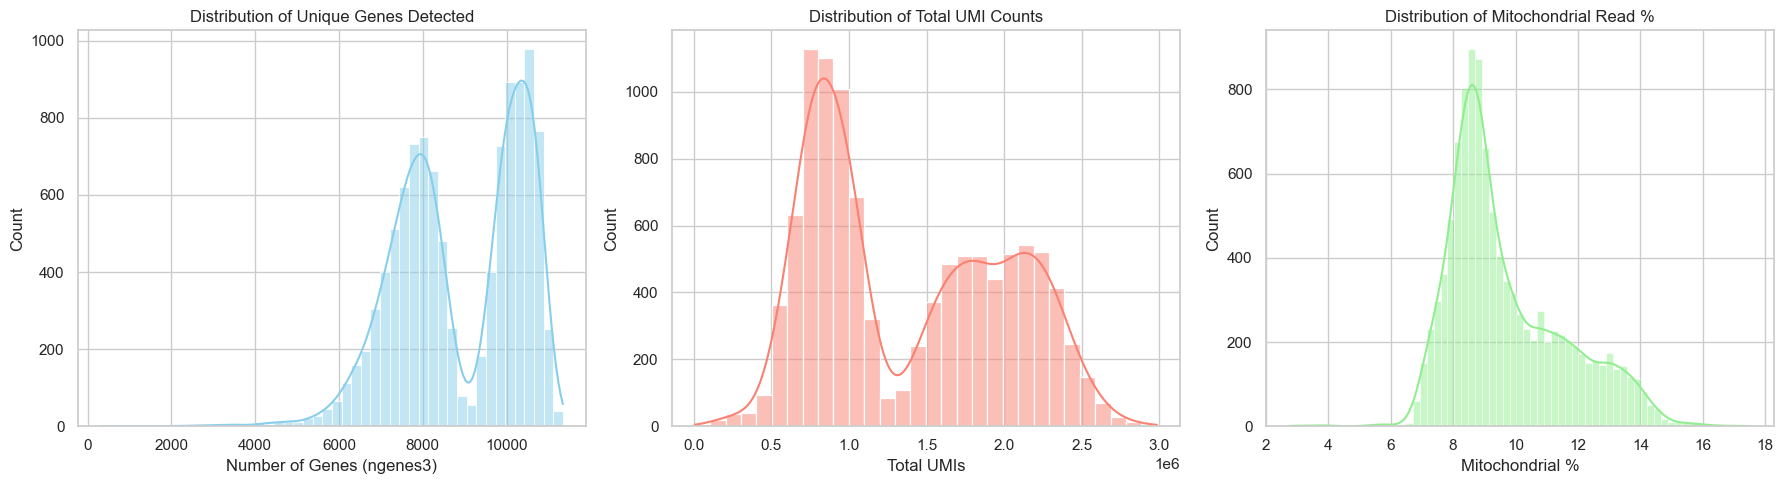

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Distribution of unique genes detected
sns.histplot(data=df, x="ngenes3", kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Unique Genes Detected")
axes[0].set_xlabel("Number of Genes (ngenes3)")

# 2. Distribution of total UMI counts (transcript abundance)
sns.histplot(data=df, x="total_umi_count", kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribution of Total UMI Counts")
axes[1].set_xlabel("Total UMIs")

# 3. Distribution of Mitochondrial read percentage (Cell stress/viability)
sns.histplot(data=df, x="percent_mitochondrial", kde=True, ax=axes[2], color="lightgreen")
axes[2].set_title("Distribution of Mitochondrial Read %")
axes[2].set_xlabel("Mitochondrial %")

plt.tight_layout()
plt.show()

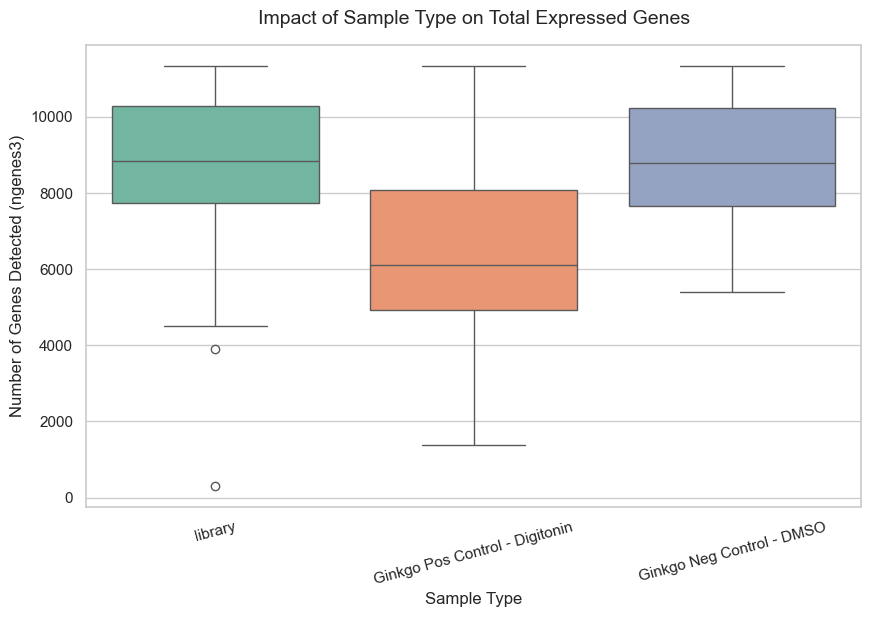

In [18]:
plt.figure(figsize=(10, 6))

# Boxplot comparing how different sample types alter the total number of genes expressed
sns.boxplot(
    data=df, 
    x="sample_type", 
    y="ngenes3", 
    hue="sample_type", 
    palette="Set2", 
    legend=False
)

plt.title("Impact of Sample Type on Total Expressed Genes", fontsize=14, pad=15)
plt.xlabel("Sample Type", fontsize=12)
plt.ylabel("Number of Genes Detected (ngenes3)", fontsize=12)
plt.xticks(rotation=15)

plt.show()

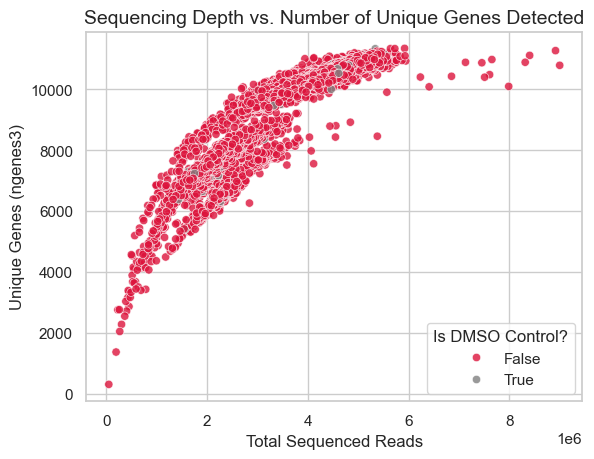

In [19]:
# Scatter plot tracking complexity vs. sequencing depth, colored by control status
sns.scatterplot(
    data=df, 
    x="total_sequenced_reads", 
    y="ngenes3", 
    hue="is_neg_control", 
    alpha=0.8, 
    palette={True: "gray", False: "crimson"}
)

plt.title("Sequencing Depth vs. Number of Unique Genes Detected", fontsize=14)
plt.xlabel("Total Sequenced Reads", fontsize=12)
plt.ylabel("Unique Genes (ngenes3)", fontsize=12)
plt.legend(title="Is DMSO Control?")

plt.show()

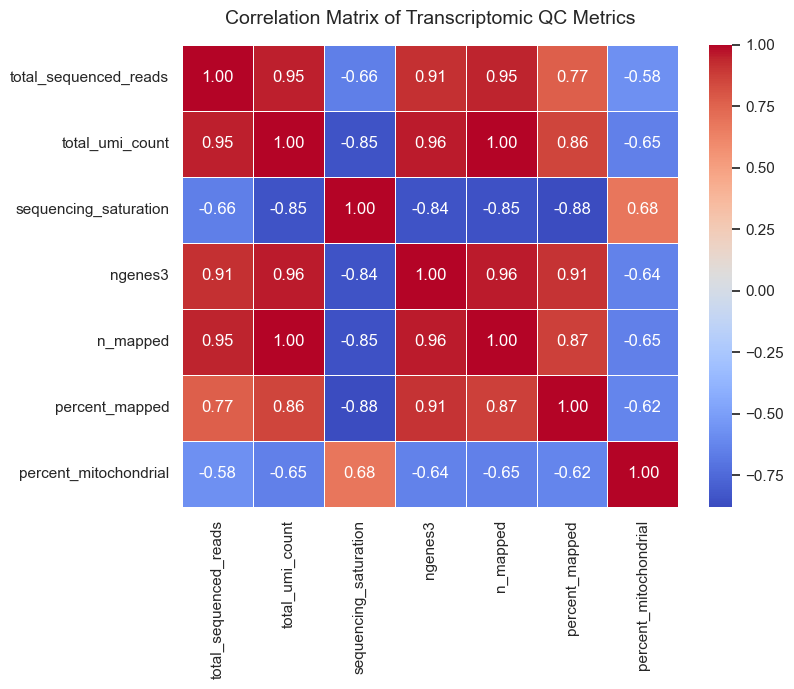

In [20]:
# Select key numeric QC metrics
qc_columns = [
    "total_sequenced_reads", "total_umi_count", "sequencing_saturation", 
    "ngenes3", "n_mapped", "percent_mapped", "percent_mitochondrial"
]

# Compute correlation matrix
corr_matrix = df[qc_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Transcriptomic QC Metrics", fontsize=14, pad=15)

plt.show()

In [28]:
compounds = df[~df['sample_type'].str.contains('Control', na=False)]['compound'].unique().tolist()

print(f"Found {len(compounds)} unique active compounds to look up.")

Found 1263 unique active compounds to look up.


In [29]:
compounds

['(±)-Vanillylmandelic acid',
 'L-2-aminoadipic acid',
 '2-methoxyestradiol',
 'Oleic Acid',
 '4-Hydroxy-3-methoxyphenylacetic acid',
 'L-Aspartic acid',
 'D-Serine',
 '5-Fluorouracil',
 'Melatonin',
 '4-Imidazoleacrylic acid',
 'N-Methyl-D-aspartic acid',
 '1,7-Dimethylxanthine',
 'Theobromine',
 'N-Acetyl-L-Cysteine',
 'Taurine',
 'Theophylline',
 "Uridine 5'-diphosphate sodium",
 'Phosphonoacetic acid',
 'L-Arginine',
 'Forskolin',
 '6-Aminohexanoic acid',
 'Protoporphyrin IX disodium',
 'Estrone',
 '2,3-Butanedione',
 'Azelaic acid',
 'Cortisone',
 'Acetamide',
 'Hypotaurine',
 '3,4-Dihydroxyphenylacetic acid',
 'Quinolinic acid',
 'O-Phospho-L-serine',
 'Hydroquinone',
 'L-3,4-Dihydroxyphenylalanine',
 'Caffeine',
 'L-Tryptophan',
 'Retinoic acid',
 'GABA',
 'L-Glutamine',
 '5-Hydroxy-L-tryptophan',
 'Adenosine',
 'N-Acetyl-5-hydroxytryptamine',
 '5-Hydroxyindolacetic acid',
 'Cortexolone',
 'Kynurenic acid',
 "Adenosine 3',5'-cyclic monophosphate",
 'Hydrocortisone',
 'ISRIB',
 '

In [31]:
import time
def get_smiles_from_chembl(compound_name):
    """Queries ChEMBL API by molecule name and extracts canonical SMILES."""
    url = f"https://www.ebi.ac.uk/chembl/api/data/molecule.json"
    params = {
        'pref_name__iexact': compound_name,  # Case-insensitive name match
        'format': 'json'
    }
    
    try:
        response = requests.get(url, params=params, timeout=10)
        if response.status_code == 200:
            data = response.json()
            # Check if any matching molecules were found
            if data.get('molecules'):
                # Extract canonical SMILES from the first record's structure sub-dictionary
                structures = data['molecules'][0].get('molecule_structures', {})
                if structures:
                    return structures.get('canonical_smiles', None)
        return None
    except Exception as e:
        return None

# Dictionary to hold our mapping results
smiles_mapping = {}

print("Starting ChEMBL structural lookup...")
for i, comp in enumerate(compounds):
    smiles = get_smiles_from_chembl(comp)
    smiles_mapping[comp] = smiles
    
    # Progress check
    if (i + 1) % 10 == 0 or (i + 1) == len(compounds):
        print(f"Processed {i + 1}/{len(compounds)} compounds...")
        
    # Politeness delay to prevent getting rate-limited by ChEMBL
    time.sleep(0.2)

print("Lookup complete!")

Starting ChEMBL structural lookup...
Processed 10/1263 compounds...
Processed 20/1263 compounds...
Processed 30/1263 compounds...
Processed 40/1263 compounds...
Processed 50/1263 compounds...
Processed 60/1263 compounds...
Processed 70/1263 compounds...
Processed 80/1263 compounds...
Processed 90/1263 compounds...
Processed 100/1263 compounds...
Processed 110/1263 compounds...
Processed 120/1263 compounds...
Processed 130/1263 compounds...
Processed 140/1263 compounds...
Processed 150/1263 compounds...
Processed 160/1263 compounds...
Processed 170/1263 compounds...
Processed 180/1263 compounds...
Processed 190/1263 compounds...
Processed 200/1263 compounds...
Processed 210/1263 compounds...
Processed 220/1263 compounds...
Processed 230/1263 compounds...
Processed 240/1263 compounds...
Processed 250/1263 compounds...
Processed 260/1263 compounds...
Processed 270/1263 compounds...
Processed 280/1263 compounds...
Processed 290/1263 compounds...
Processed 300/1263 compounds...
Processed 31

In [40]:
get_smiles_from_chembl(comp)

In [41]:
comp

'KB-R7493'

In [43]:
compounds

['(±)-Vanillylmandelic acid',
 'L-2-aminoadipic acid',
 '2-methoxyestradiol',
 'Oleic Acid',
 '4-Hydroxy-3-methoxyphenylacetic acid',
 'L-Aspartic acid',
 'D-Serine',
 '5-Fluorouracil',
 'Melatonin',
 '4-Imidazoleacrylic acid',
 'N-Methyl-D-aspartic acid',
 '1,7-Dimethylxanthine',
 'Theobromine',
 'N-Acetyl-L-Cysteine',
 'Taurine',
 'Theophylline',
 "Uridine 5'-diphosphate sodium",
 'Phosphonoacetic acid',
 'L-Arginine',
 'Forskolin',
 '6-Aminohexanoic acid',
 'Protoporphyrin IX disodium',
 'Estrone',
 '2,3-Butanedione',
 'Azelaic acid',
 'Cortisone',
 'Acetamide',
 'Hypotaurine',
 '3,4-Dihydroxyphenylacetic acid',
 'Quinolinic acid',
 'O-Phospho-L-serine',
 'Hydroquinone',
 'L-3,4-Dihydroxyphenylalanine',
 'Caffeine',
 'L-Tryptophan',
 'Retinoic acid',
 'GABA',
 'L-Glutamine',
 '5-Hydroxy-L-tryptophan',
 'Adenosine',
 'N-Acetyl-5-hydroxytryptamine',
 '5-Hydroxyindolacetic acid',
 'Cortexolone',
 'Kynurenic acid',
 "Adenosine 3',5'-cyclic monophosphate",
 'Hydrocortisone',
 'ISRIB',
 '

In [35]:
###### look into gene_counts parquet
# !pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Load the count matrix
counts_df = pd.read_parquet("../gene_counts-2.parquet")

# If 'gene_symbol' or 'gene_id' is a column, set it as the index
if 'gene_id' in counts_df.columns:
    counts_df = counts_df.set_index('gene_id')
elif 'gene_symbol' in counts_df.columns:
    counts_df = counts_df.set_index('gene_symbol')

print(f"Matrix Shape: {counts_df.shape[0]} genes across {counts_df.shape[1]} samples.")

# Calculate sparsity (percentage of zeros in the dataset)
zero_percentage = (counts_df == 0).sum().sum() / counts_df.size * 100
print(f"Dataset Sparsity: {zero_percentage:.2f}% of the matrix is zeros.")

Matrix Shape: 59427 genes across 10672 samples.
Dataset Sparsity: 79.05% of the matrix is zeros.


In [36]:
counts_df

,98842119,98842729,98838038,98842728,98842087,98840465,98842740,98840480,98842108,98842741,...,98845064,98845063,98845061,98845053,98845052,98845060,98845066,98839557,98842675,98841962
gene_name,,,,,,,,,,,,,,,,,,,,,
DDX11L1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
WASH7P,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MIR6859-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MIR1302-2HG,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MIR1302-2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-ND6,645,601,488,578,660,762,623,866,789,562,...,270,237,327,190,249,188,183,735,621,673
MT-TE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
MT-CYB,5863,4967,4954,4003,6130,6020,4500,6105,6116,4708,...,3413,3079,3614,3216,2531,2566,2247,7071,4729,6142


In [37]:
smiles

In [ ]:
#### GDPX1 has files for gene_counts : gene_counts-2.parquet
